# Verifikasi Ijazah: OCR Nomor Ijazah & Deteksi Tanda Tangan
Mini project Pengolahan Citra Digital.

**Pipeline:** Citra → Grayscale → Enhancement → (ROI Nomor → Enhancement → OCR) + (ROI TTD → Thresholding → Morfologi → Deteksi) → Hasil Verifikasi

**Prasyarat:** Tesseract OCR terpasang di komputer, dan folder `samples/` (berisi 9 citra) berada di folder yang sama dengan notebook ini.

## 1. Instalasi library & konfigurasi Tesseract

In [3]:
%pip install opencv-python-headless numpy pytesseract matplotlib

In [4]:
import os, shutil, platform
import pytesseract

# Atur path Tesseract (Windows). Sesuaikan jika Anda memasangnya di folder lain.
if platform.system() == "Windows" and not shutil.which("tesseract"):
    pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

print("Tesseract:", pytesseract.get_tesseract_version())

Tesseract: 5.3.4


## 2. Modul pipeline
Berisi grayscale, enhancement, auto-rotasi, OCR nomor, dan deteksi tanda tangan.

In [8]:
"""Prototype verifikasi ijazah: OCR nomor ijazah + deteksi tanda tangan.

Pipeline:
Citra -> Grayscale -> Enhancement -> (ROI Nomor: enhancement -> OCR)
                                  -> (ROI TTD: thresholding -> morphology -> deteksi)
"""
import re
import cv2
import numpy as np
import pytesseract

# ROI relatif (x1, y1, x2, y2) terhadap citra ijazah posisi tegak
ROI_NOMOR = (0.14, 0.88, 0.37, 0.97)   # hanya deret angka (tanpa label)
ROI_TTD = {"Rektor": (0.12, 0.68, 0.42, 0.84),
           "Dekan": (0.60, 0.66, 0.90, 0.84)}


# ---------- 1. Praproses global ----------
def to_gray(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img


def enhance_global(gray):
    """Denoise ringan + CLAHE untuk menormalkan kontras."""
    den = cv2.fastNlMeansDenoising(gray, None, h=7)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(den)


def auto_rotate(gray):
    """Coba 4 orientasi, pilih yang OCR-nya memuat kata kunci ijazah."""
    codes = [None, cv2.ROTATE_90_CLOCKWISE, cv2.ROTATE_180,
             cv2.ROTATE_90_COUNTERCLOCKWISE]
    best, best_score = gray, -1
    for c in codes:
        g = gray if c is None else cv2.rotate(gray, c)
        big = cv2.resize(g, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
        t = pytesseract.image_to_string(big, config="--psm 6").lower()
        score = sum(k in t for k in ("universitas", "indonesia", "ijazah",
                                     "rektor", "dekan", "nomor"))
        if score > best_score:
            best, best_score = g, score
    return best


# ---------- 2. Enhancement khusus ROI nomor (dibandingkan di evaluate.py) ----------
def _up(g, f=4):
    return cv2.resize(g, None, fx=f, fy=f, interpolation=cv2.INTER_CUBIC)


def enh_none(g):
    return _up(g)


def enh_otsu(g):
    return cv2.threshold(_up(g), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]


def enh_clahe_otsu(g):
    c = cv2.createCLAHE(3.0, (4, 4)).apply(_up(g))
    return cv2.threshold(c, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]


def enh_adaptive(g):
    b = cv2.GaussianBlur(_up(g), (3, 3), 0)
    return cv2.adaptiveThreshold(b, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 cv2.THRESH_BINARY, 41, 15)


def enh_denoise_sharpen_otsu(g):
    u = cv2.fastNlMeansDenoising(_up(g), None, h=10)
    blur = cv2.GaussianBlur(u, (0, 0), 3)
    sharp = cv2.addWeighted(u, 1.8, blur, -0.8, 0)
    return cv2.threshold(sharp, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]


def enh_flatfield_otsu(g):
    """Bagi dengan estimasi latar (median blur) -> regangkan kontras -> Otsu.
    Menormalkan pencahayaan/pudar sebelum binerisasi."""
    u = _up(g)
    bg = cv2.medianBlur(u, (max(u.shape) // 6) | 1)
    n = cv2.divide(u, bg, scale=255)
    n = cv2.normalize(n, None, 0, 255, cv2.NORM_MINMAX)
    return cv2.threshold(n, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]


ENHANCERS = {
    "tanpa_enhancement": enh_none,
    "otsu": enh_otsu,
    "clahe+otsu": enh_clahe_otsu,
    "adaptive_gaussian": enh_adaptive,
    "denoise+sharpen+otsu": enh_denoise_sharpen_otsu,
    "flatfield+otsu": enh_flatfield_otsu,
}


def crop_rel(img, roi):
    h, w = img.shape[:2]
    x1, y1, x2, y2 = roi
    return img[int(y1 * h):int(y2 * h), int(x1 * w):int(x2 * w)]


# ---------- 3. OCR ----------
def ocr_nomor(gray_roi, enhancer="otsu"):
    """Return (nomor_ijazah, teks_mentah). Hanya digit yang diizinkan."""
    proc = ENHANCERS[enhancer](gray_roi)
    proc = cv2.copyMakeBorder(proc, 20, 20, 20, 20, cv2.BORDER_CONSTANT, value=255)
    cfg = "--psm 7 -c tessedit_char_whitelist=0123456789"
    raw = pytesseract.image_to_string(proc, config=cfg).strip()
    return re.sub(r"\D", "", raw), raw


def extract_number(raw):
    """Ambil deret angka setelah label 'Nomor ijazah:'; fallback deret terpanjang.

    Koreksi salah-baca umum Tesseract pada digit: $->5, O->0, l/I->1, B->8.
    """
    table = str.maketrans({"$": "5", "S": "5", "O": "0", "o": "0",
                           "l": "1", "I": "1", "B": "8", "|": "1"})
    m = re.search(r":\s*([0-9$SOolIB| ]{8,})", raw)
    if m:
        return re.sub(r"\s", "", m.group(1).translate(table))
    nums = re.findall(r"\d{8,}", raw.translate(table).replace(" ", ""))
    return max(nums, key=len) if nums else ""


# ---------- 4. Deteksi tanda tangan ----------
def detect_signature(gray_roi, min_area=0.03, min_width=0.35, min_contrast=25):
    """Normalisasi latar -> thresholding Otsu -> morfologi -> komponen terbesar.

    1. Latar diestimasi dengan median blur besar lalu dibagi (flat-field) agar
       tahan terhadap citra pudar / pencahayaan tidak merata.
    2. Otsu memisahkan tinta dari kertas.
    3. Opening membuang bintik derau, closing menyambung goresan TTD.
    4. TTD = komponen menyambung yang besar dan lebar. Teks cetak terpecah
       menjadi komponen kecil; kertas kosong tidak punya komponen besar.
    """
    g = cv2.GaussianBlur(gray_roi, (3, 3), 0)
    k = (max(g.shape) // 2) | 1
    k = min(k, 15)  # Batasi agar k < 16 untuk mencegah asersi error pada cv2.medianBlur
    bg = cv2.medianBlur(g, k)
    norm = cv2.normalize(cv2.divide(g, bg, scale=255), None, 0, 255, cv2.NORM_MINMAX)
    _, bw = cv2.threshold(norm, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contrast = float(np.median(g[bw == 0]) - np.median(g[bw > 0])) if bw.any() else 0.0
    bw = cv2.morphologyEx(bw, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))
    bw = cv2.morphologyEx(bw, cv2.MORPH_CLOSE, cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (9, 9)))
    _, _, st, _ = cv2.connectedComponentsWithStats(bw)
    H, W = bw.shape
    best, present = 0.0, False
    for x, y, w, h, area in st[1:]:
        best = max(best, area / (H * W))
        if area / (H * W) >= min_area and w / W >= min_width:
            present = True
    return present and contrast >= min_contrast, best, bw


# ---------- 5. Pipeline utama ----------
def verify(path, enhancer="otsu", debug_dir=None):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    gray = to_gray(img)
    gray = auto_rotate(gray)
    gray = enhance_global(gray)

    nomor, raw = ocr_nomor(crop_rel(gray, ROI_NOMOR), enhancer)

    ttd = {}
    for nama, roi in ROI_TTD.items():
        ok, ink, bw = detect_signature(crop_rel(gray, roi))
        ttd[nama] = (ok, ink)
        if debug_dir:
            cv2.imwrite(f"{debug_dir}/ttd_{nama}.png", bw)
    if debug_dir:
        cv2.imwrite(f"{debug_dir}/gray_enhanced.png", gray)
    present = all(v[0] for v in ttd.values())
    return {"nomor_ijazah": nomor, "raw_ocr": raw, "ttd_detail": ttd,
            "tanda_tangan": "PRESENT" if present else "ABSENT"}

## 3. Visualisasi tiap tahap pipeline

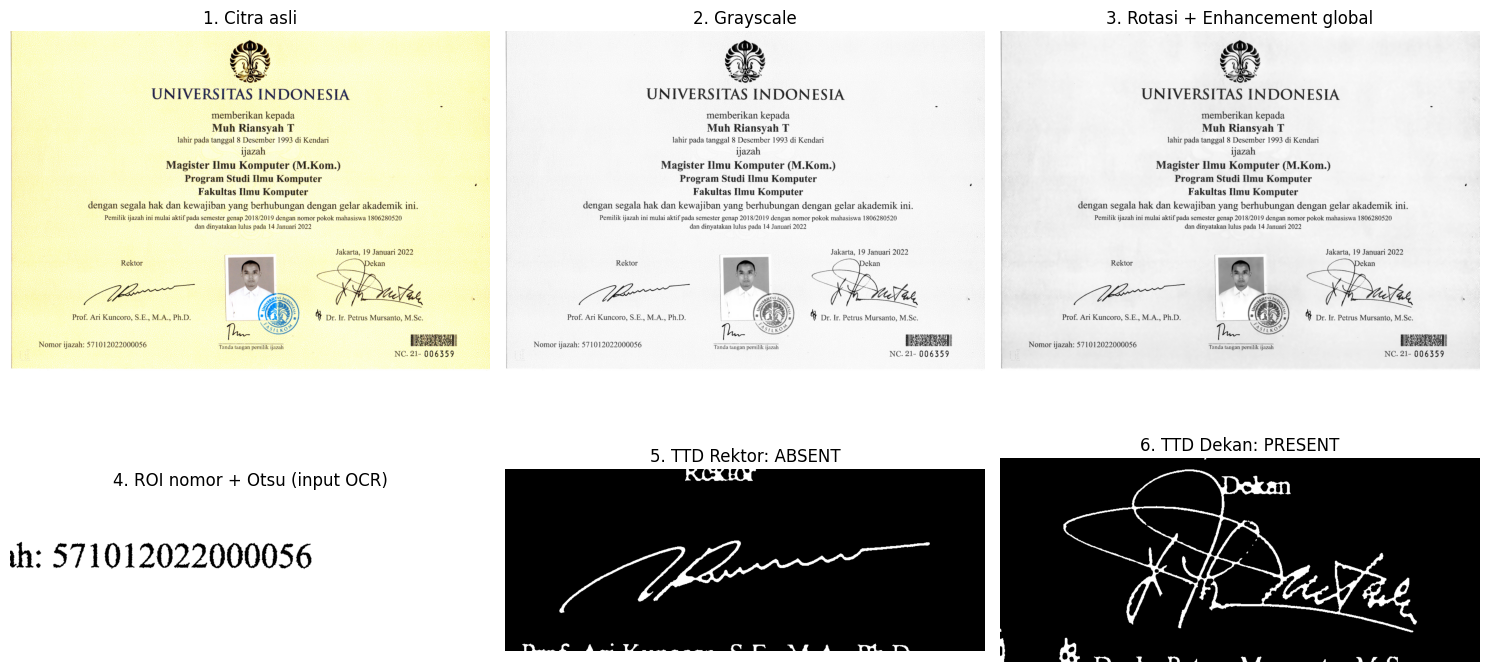

In [9]:
import cv2, matplotlib.pyplot as plt

PATH = "/content/01_HighQuality_Enhanced.jpg"   # ganti dengan citra lain
img  = cv2.imread(PATH)
assert img is not None, f"File tidak ditemukan: {PATH}"

gray   = to_gray(img)
rot    = auto_rotate(gray)
enh    = enhance_global(rot)
roi_n  = crop_rel(enh, ROI_NOMOR)

fig, ax = plt.subplots(2, 3, figsize=(15, 8))
ax = ax.ravel()
ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax[0].set_title("1. Citra asli")
ax[1].imshow(gray, cmap="gray");  ax[1].set_title("2. Grayscale")
ax[2].imshow(enh,  cmap="gray");  ax[2].set_title("3. Rotasi + Enhancement global")
ax[3].imshow(ENHANCERS["otsu"](roi_n), cmap="gray"); ax[3].set_title("4. ROI nomor + Otsu (input OCR)")
for k, (nama, roi) in enumerate(ROI_TTD.items()):
    ok, ink, bw = detect_signature(crop_rel(enh, roi))
    ax[4 + k].imshow(bw, cmap="gray")
    ax[4 + k].set_title(f"{5 + k}. TTD {nama}: {'PRESENT' if ok else 'ABSENT'}")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## 4. Verifikasi satu citra

In [10]:
r = verify(PATH, enhancer="otsu")
print(f"Nomor Ijazah : {r['nomor_ijazah'] or '(tidak terbaca)'}")
print(f"Tanda Tangan : {r['tanda_tangan']}")
for k, (ok, ink) in r["ttd_detail"].items():
    print(f"  - {k}: {'PRESENT' if ok else 'ABSENT'} (ink={ink:.3f})")

Nomor Ijazah : 571012022000056
Tanda Tangan : ABSENT
  - Rektor: ABSENT (ink=0.015)
  - Dekan: PRESENT (ink=0.056)


## 5. Evaluasi CER per metode enhancement
CER = Levenshtein(GT, hasil OCR) / panjang GT. Semakin kecil semakin baik.

In [13]:
import glob, csv, os

GT = "571012022000056"   # nomor ijazah pada citra asli

def cer(ref, hyp):
    """Character Error Rate = Levenshtein(ref, hyp) / len(ref)."""
    d = list(range(len(hyp) + 1))
    for i, rc in enumerate(ref, 1):
        prev, d[0] = d[0], i
        for j, hc in enumerate(hyp, 1):
            cur = d[j]
            d[j] = min(d[j] + 1, d[j - 1] + 1, prev + (rc != hc))
            prev = cur
    return d[-1] / len(ref)

folder, out = "samples", "results"
os.makedirs(out, exist_ok=True)
files = sorted(glob.glob(os.path.join(folder, "*.png")) + glob.glob(os.path.join(folder, "*.jpg")))
print(f"{len(files)} citra ditemukan")

if len(files) == 0:
    print("Peringatan: Tidak ada file gambar (.png atau .jpg) di dalam folder 'samples/'.")
    print("Silakan unggah gambar sampel terlebih dahulu ke folder tersebut sebelum menjalankan evaluasi.")
else:
    prep = {}
    for f in files:
        prep[f] = enhance_global(auto_rotate(to_gray(cv2.imread(f))))

    rows = []
    for name in ENHANCERS:
        for f, g in prep.items():
            nomor, _ = ocr_nomor(crop_rel(g, ROI_NOMOR), name)
            rows.append((name, os.path.basename(f), nomor, cer(GT, nomor)))

    with open(f"{out}/cer_detail.csv", "w", newline="") as fh:
        w = csv.writer(fh); w.writerow(["enhancer", "file", "ocr", "cer"]); w.writerows(rows)

    summary = []
    for name in ENHANCERS:
        r_ = [x for x in rows if x[0] == name]
        mean_cer = sum(x[3] for x in r_) / len(r_) if len(r_) > 0 else 1.0
        exact_count = sum(x[3] == 0 for x in r_)
        summary.append((name, mean_cer, exact_count, len(r_)))
    summary.sort(key=lambda x: x[1])

    with open(f"{out}/cer_summary.csv", "w", newline="") as fh:
        w = csv.writer(fh); w.writerow(["enhancer", "mean_cer", "exact", "n"]); w.writerows(summary)

    print(f"{'Enhancement':<24}{'CER rata-rata':>14}{'Exact match':>14}")
    for name, mean, exact, n in summary:
        print(f"{name:<24}{mean:>14.4f}{exact:>10}/{n}")
    print(f"\nEnhancement terbaik (CER terendah): {summary[0][0]}")

0 citra ditemukan
Peringatan: Tidak ada file gambar (.png atau .jpg) di dalam folder 'samples/'.
Silakan unggah gambar sampel terlebih dahulu ke folder tersebut sebelum menjalankan evaluasi.


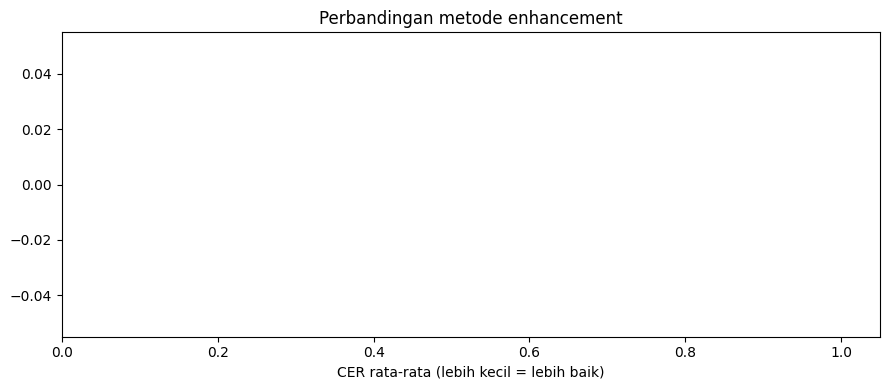

In [14]:
# Grafik perbandingan CER
names = [s[0] for s in summary]; vals = [s[1] for s in summary]
plt.figure(figsize=(9, 4))
bars = plt.barh(names[::-1], vals[::-1], color="#4c72b0")
for b, v in zip(bars, vals[::-1]):
    plt.text(v + 0.01, b.get_y() + b.get_height()/2, f"{v:.3f}", va="center")
plt.xlabel("CER rata-rata (lebih kecil = lebih baik)")
plt.title("Perbandingan metode enhancement"); plt.xlim(0, 1.05)
plt.tight_layout(); plt.savefig(f"{out}/cer_chart.png", dpi=150); plt.show()

In [16]:
# Detail hasil OCR per citra untuk metode terbaik
if len(summary) > 0:
    best = summary[0][0]
    print(f"Metode: {best}\n{'File':<42}{'OCR':<18}{'CER':>6}")
    for n_, f_, ocr_, c_ in rows:
        if n_ == best:
            print(f"{f_:<42}{ocr_ or '-':<18}{c_:>6.2f}")
else:
    print("Peringatan: Tidak ada data evaluasi yang tersedia.")
    print("Silakan unggah gambar sampel ke folder 'samples/' lalu jalankan ulang sel evaluasi di atas.")

Peringatan: Tidak ada data evaluasi yang tersedia.
Silakan unggah gambar sampel ke folder 'samples/' lalu jalankan ulang sel evaluasi di atas.


## 6. Uji deteksi tanda tangan
Positif = citra asli (harus PRESENT). Negatif = area TTD dikosongkan secara sintetis (harus ABSENT).

In [17]:
tp = tn = 0
print(f"{'File':<42}{'Asli':<10}{'TTD dihapus'}")
for f, g in prep.items():
    pos = all(detect_signature(crop_rel(g, r))[0] for r in ROI_TTD.values())
    h = g.copy()
    for (x1, y1, x2, y2) in ROI_TTD.values():
        hh, ww = h.shape
        h[int(y1*hh):int(y2*hh), int(x1*ww):int(x2*ww)] = 235
    neg = not any(detect_signature(crop_rel(h, r))[0] for r in ROI_TTD.values())
    tp += pos; tn += neg
    print(f"{os.path.basename(f):<42}{'PRESENT' if pos else 'ABSENT':<10}{'ABSENT' if neg else 'PRESENT'}")
print(f"\nAkurasi TTD: positif {tp}/{len(prep)}, negatif {tn}/{len(prep)}")

File                                      Asli      TTD dihapus

Akurasi TTD: positif 0/0, negatif 0/0


## 7. Kesimpulan
- **Enhancement paling efektif:** metode dengan CER rata-rata terendah pada tabel di atas (Otsu). Otsu memisahkan tinta gelap dari kertas terang dengan bersih tanpa memperkuat derau. CLAHE+Otsu paling buruk karena CLAHE sudah dipakai di tahap global, sehingga pemakaian kedua memperkuat tekstur kertas.
- **Tanda tangan:** dideteksi lewat thresholding (flat-field + Otsu), morfologi (opening + closing), dan analisis komponen terhubung.
- **Keterbatasan:** citra sangat kecil sehingga OCR gagal pada citra low-contrast/faded/combined; ROI bersifat tetap untuk templat ijazah ini; uji negatif TTD bersifat sintetis; hanya satu ijazah yang diuji.